In [5]:
import vcf
import sys
import pandas as pd
import math
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import allel
import numpy as np
import msprime
import demesdraw
from sklearn import metrics

<h2>Figure 1</h2>

In [ ]:
#####CALCULATE SUMMARY STATISTICS FOR DFE SIMULATIONS#####
####CALCULATE SIMULATED SUMMARY STATS####
for data in ['DFE1', 'human', 'marmoset']:
    theta = []
    tajd = []
    noSing = []
    div = []
    if data == 'DFE1':
        maxRange = 201
    else:
        maxRange = 101
    for i in range(1, maxRange):
        try:
            v = allel.read_vcf(f'/Volumes/WD/titi/DFE/sims/{data}_rep{i}.vcf.gz')
            #Get genotype array
            gt = allel.GenotypeArray(v['calldata/GT'])
            #Get allele counts
            ac = gt.count_alleles()
            theta.append(allel.watterson_theta(v['variants/POS'], ac, start=1, stop=618))
            tajd.append(allel.tajima_d(ac, start=1, stop=618))
            noSing.append(allel.sfs_folded(ac)[1] / 618)
            f_fixed = f"/Volumes/WD/titi/DFE/sims/{data}_rep{i}.fixed"
            div.append(get_divergence(f_fixed=f_fixed, chr_len=618))
        except Exception:
            theta.append(0)
            tajd.append(np.nan)
            noSing.append(0)
            f_fixed = f"/Volumes/WD/titi/DFE/sims/{data}_rep{i}.fixed"
            div.append(get_divergence(f_fixed=f_fixed, chr_len=618))
    df = pd.DataFrame([theta, tajd, noSing, div]).T 
    df.columns=['thetaw', 'tajimasd', 'numsingletons', 'divergence']
    
    df.to_csv(f"/Volumes/WD/titi/DFE/{data}_summary_stats.bed", sep='\t', header=True, index=False)

In [3]:
edf = pd.read_csv(f"/Volumes/WD/titi/DFE/exonic_summary_stats.bed", sep='\t', header=0)
ddf = pd.read_csv(f"/Volumes/WD/titi/DFE/DFE1_summary_stats.bed", sep='\t', header=0)

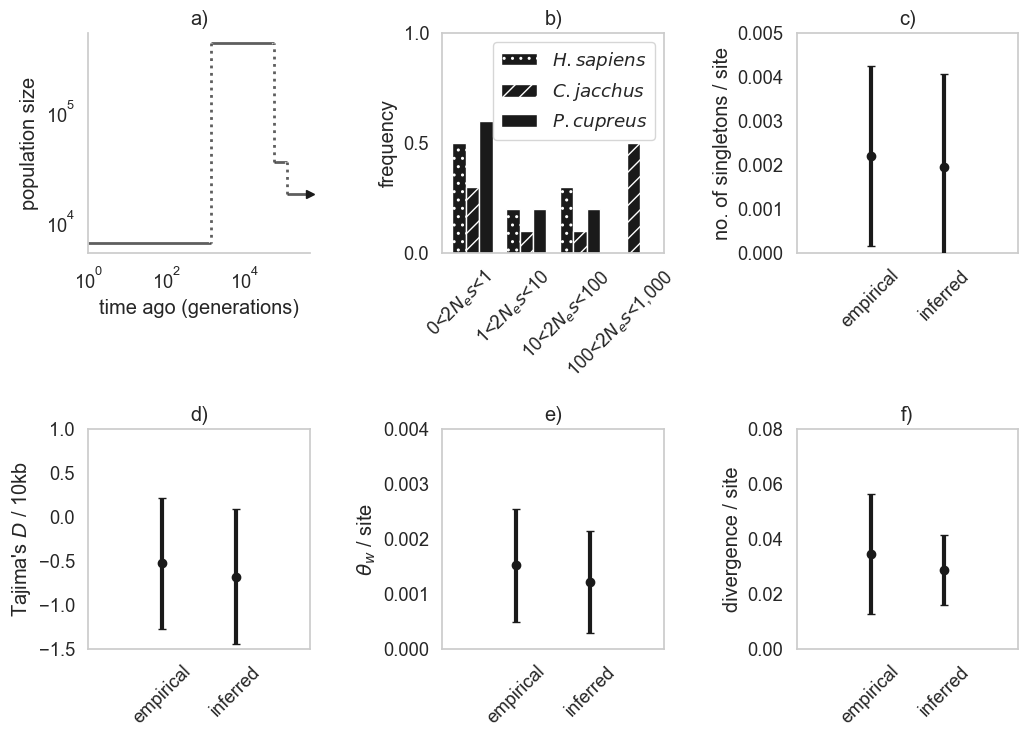

In [4]:
t_list = ['a)', 'b)', 'c)','d)','e)','f)']
#Set y axes limits
ylims = [[0,0.005], [-1.5, 1], [0,0.004]]
sns.set(rc={'figure.figsize':(12, 8),'axes.facecolor':'white','axes.edgecolor': '.8'},font_scale=1.2)
plt.figure(figsize=(12, 8))
ax1 = plt.subplot(2,3,1)
ax2 = plt.subplot(2,3,2)
ax3 = plt.subplot(2,3,3)
ax4 = plt.subplot(2,3,4)
ax5 = plt.subplot(2,3,5)
ax6 = plt.subplot(2,3,6)

#Generate demog model using msprime
# #Based on 1.07e-8 mutation rate (see Terbot et al. 2026)
N_current = 6330
t1 = 1406
N1 = 424862.5
t2 = 55881
N2 = 34933.5
t3 = 122126
N3 = 17807
Nancestral = N3
demography = msprime.Demography()
demography.add_population(
    name="titi",
    description="titi population",
    initial_size=N_current,
    growth_rate=0,
    default_sampling_time=0, 
    initially_active=True,
)

#Add events
demography.add_population_parameters_change(initial_size=N1, time=t1, growth_rate=0, population="titi")
demography.add_population_parameters_change(initial_size=N2, time=t2, growth_rate=0, population="titi")
demography.add_population_parameters_change(initial_size=N3, time=t3, growth_rate=0, population="titi")
demography.sort_events
#Plot using demesdraw
graph = msprime.Demography.to_demes(demography)
demesdraw.size_history(graph, ax=ax1, log_time=True, colours='k', log_size=True)
ax1.set_ylabel('population size', rotation=90, labelpad=5)
ax1.set_title(t_list[0])

#Plot DFEs
human = [0.5,0.2,0.3,0] #Obtained from Johri et al. (2023)
marm = [0.3,0.1,0.1,0.5] #Obtained from Soni et al. (2025)
DFE1 = [0.6,0.2,0.2,0]
DFE_x = [a for a in range(0,4)]
ax2.bar(x=DFE_x, height=human, color='k', width=0.25, label=r'$H. sapiens$', hatch='..')
ax2.bar(x=[x+0.25 for x in DFE_x], height=marm, color='k', width=0.25, label=r'$C. jacchus$', hatch='//')
ax2.bar(x=[x+0.5 for x in DFE_x], height=DFE1, color='k', width=0.25, label=r'$P. cupreus$')
ax2.set_ylabel('frequency')
ax2.set_xticks(DFE_x)
ax2.set_xticklabels([r'0<2$N_es$<1', r'1<2$N_es$<10', r'10<2$N_es$<100', r'100<2$N_es$<1,000'], rotation=45) 
#plt.xticklabels([r'2$N_es$<10', r'10<2$N_es$<100', r'100<2$N_es$<1,000'], rotation=45)
ax2.set_yticks([0, 0.5, 1])
ax2.set_title(t_list[1])
ax2.legend()

#Plot summary statistics
titles = ['no. of singletons / site', r"Tajima's $D$ / 10kb", r'$\theta_w$ / site']
lst = [ax3, ax4, ax5]
for i,stat in enumerate(['numsingletons', 'tajimasd', 'thetaw']):
    lst[i].errorbar([0.95], edf[stat].mean(), edf[stat].std(),
                        fmt='o', lw=3, capsize=3, zorder=15, c='k', label='empirical')

    lst[i].errorbar([1], ddf[stat].mean(), ddf[stat].std(),
                        fmt='o', lw=3, capsize=3, zorder=15, c='k', label='inferred')
    
    lst[i].set_ylim(ylims[i])
    lst[i].set_xticks([0.9, 0.95, 1, 1.05])
    lst[i].set_xticklabels(['','empirical','inferred',''], rotation=45)
    lst[i].set_ylabel(titles[i])
    lst[i].set_title(t_list[i+2])
        

ax6.errorbar([0.95], edf['divergence'].mean(), edf['divergence'].std(),
                    fmt='o', lw=3, capsize=3, zorder=15, c='k', label='empirical')

ax6.errorbar([1], ddf['divergence'].mean(), ddf['divergence'].std(),
                    fmt='o', lw=3, capsize=3, zorder=15, c='k', label='inferred')

ax6.set_ylabel('divergence / site')
ax6.set_xticks([0.9, 0.95, 1, 1.05])
ax6.set_xticklabels(['','empirical','inferred',''], rotation=45)
ax6.set_ylim([0, 0.08])
ax6.set_title(t_list[-1])



plt.subplots_adjust(wspace=0.6, hspace=0.8)
#plt.savefig(r"/Volumes/WD/titi/sweep_scans/plots/fig1.png", format='png', bbox_inches='tight')
#plt.savefig(r"/Volumes/WD/titi/sweep_scans/plots/fig1.pdf", format='pdf', dpi=350, bbox_inches='tight')

<h2>Figure 2</h2>

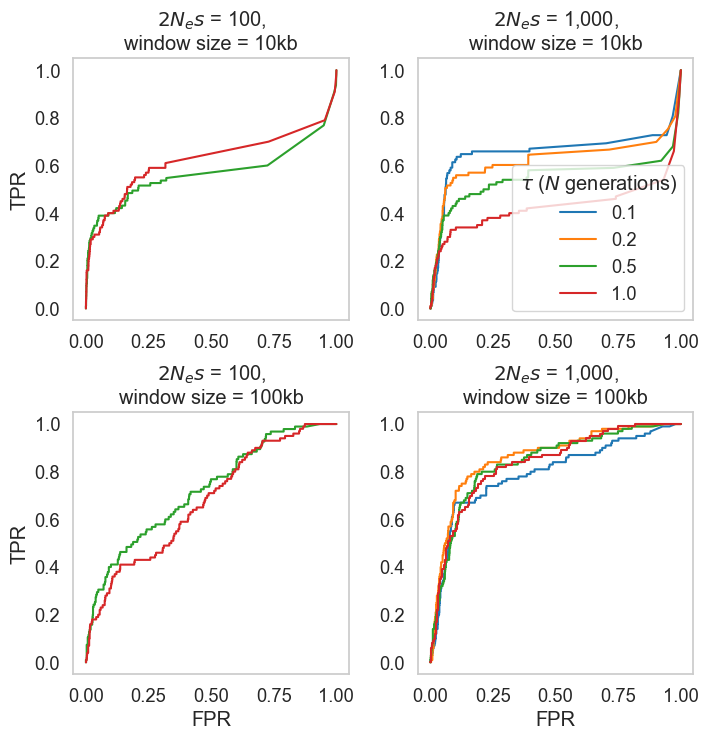

In [6]:
#create dict of colors
cols = ['tab:blue',
'tab:orange',
'tab:green',
'tab:red',
'tab:purple',
'tab:brown',
'tab:pink',
'tab:gray',
'tab:olive',
'tab:cyan']

labs = ['10kb', '100kb']
#Generate 2x2 figure
fig, axs = plt.subplots(2, 2, figsize=(8,8))
#Set total simulated region length
chr_len=1002771
#Loop through times since fixation
for i, gen in enumerate([0.5, 1.0]):
    #Loop through simulation replicates
    rdf = [pd.DataFrame() for x in range(0, 2)] 
    for rep in range(1, 101):
        #Loop through window sizes
        for w, winSize in enumerate([10000, 100000]):
            try:
                df = pd.read_csv(f"/Volumes/WD/titi/sweep_scans/power_analysis/SF2_results/{gen}_100.0_rep{rep}.clr", sep='\t', header=0)
                #Bin loci into windows
                df['bin'] = pd.cut(df.location, [x for x in range(1, chr_len+winSize, winSize)],
                                          labels=[x for x in range(1, chr_len, winSize)])
                #Identify window which contains the sweep
                sweep = ((int(math.ceil(500027 / winSize)) - 1) * winSize) + 1
                df['sweep'] = np.where(df.bin == sweep, 1, 0)
                df1 = pd.DataFrame(df.groupby('bin', observed=False)['sweep'].sum())
                df2 = pd.DataFrame(df.groupby('bin', observed=False)['LR'].max())
                df = pd.merge(df1,df2, left_index=True, right_index=True)
                df['LR'] = np.where(df.LR.isna(), 0, df.LR)
                df['sweep'] = np.where(df.sweep > 1, 1, df.sweep)
                rdf[w] = pd.concat([rdf[w], df])
            except Exception:
                pass
    for r, df in enumerate(rdf):
        y = df.sweep
        scores = df.LR
        fpr, tpr, thresholds = metrics.roc_curve(y, scores)
        axs[r,0].plot(fpr, tpr, label=str(gen), c=cols[i+2]) 
        axs[r,0].set_title("$2N_es$" + " = 100,\nwindow size = " + str(labs[r]))
        axs[r,0].set_ylabel("TPR")
    axs[1,0].set_xlabel("FPR")
    
 #Repeat for 2Nes=1000   
for i, gen in enumerate([0.1, 0.2, 0.5, 1.0]):
    rdf = [pd.DataFrame() for x in range(0, 2)] 
    for rep in range(1, 101):
        for w, winSize in enumerate([10000, 100000]):
            try:
                df = pd.read_csv(f"/Volumes/WD/titi/sweep_scans/power_analysis/SF2_results/{gen}_1000.0_rep{rep}.clr", sep='\t', header=0)
                df['bin'] = pd.cut(df.location, [x for x in range(1, chr_len+winSize, winSize)],
                                          labels=[x for x in range(1, chr_len, winSize)])
                #sweep at position 37,336
                sweep = ((int(math.ceil(500027 / winSize)) - 1) * winSize) + 1
                df['sweep'] = np.where(df.bin == sweep, 1, 0)
                df1 = pd.DataFrame(df.groupby('bin', observed=False)['sweep'].sum())
                df2 = pd.DataFrame(df.groupby('bin', observed=False)['LR'].max())
                df = pd.merge(df1,df2, left_index=True, right_index=True)
                df['LR'] = np.where(df.LR.isna(), 0, df.LR)
                df['sweep'] = np.where(df.sweep > 1, 1, df.sweep)
                rdf[w] = pd.concat([rdf[w], df])
            except Exception:
                pass
    for r, df in enumerate(rdf):
        y = df.sweep
        scores = df.LR
        fpr, tpr, thresholds = metrics.roc_curve(y, scores)
        axs[r,1].plot(fpr, tpr, label=str(gen), c=cols[i]) 
        axs[r,1].set_title("$2N_es$" + " = 1,000,\nwindow size = " + str(labs[r]))
    axs[1,1].set_xlabel("FPR")
    

        
axs[0,1].legend(title=r'$\tau$' + ' (' + '$N$' +  ' generations)')
plt.subplots_adjust(wspace=0.25, hspace=0.35)

#plt.savefig(f'/Volumes/WD/titi/sweep_scans/plots/fig2.png', format='png', bbox_inches='tight')
#plt.savefig(f'/Volumes/WD/titi/sweep_scans/plots/fig2.pdf', format='pdf', bbox_inches='tight', dpi=300)

<h2>Figure 3</h2>

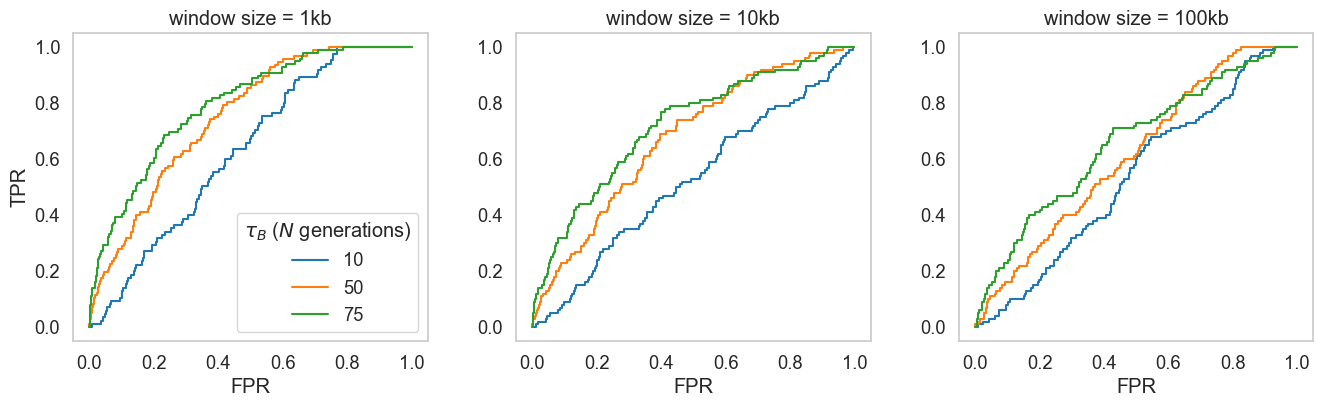

In [7]:
cols = ['tab:blue',
'tab:orange',
'tab:green',
'tab:red',
'tab:purple',
'tab:brown',
'tab:pink',
'tab:gray',
'tab:olive',
'tab:cyan']

labs = ['1kb', '10kb', '100kb']

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
chr_len=1002771

for i, gen in enumerate([10, 50, 75]):
    rdf = [pd.DataFrame() for x in range(0, 3)] 
    for rep in range(1, 101):
        for w, winSize in enumerate([1000, 10000, 100000]):
            try:
                df = pd.read_csv(f"/Volumes/WD/titi/sweep_scans/power_analysis/BM_results/{gen}_rep{rep}.clr", sep='\t', header=0)
                df['bin'] = pd.cut(df.physPos, [x for x in range(1, chr_len+winSize, winSize)],
                                          labels=[x for x in range(1, chr_len, winSize)])
                #sweep at position 37,336
                sweep = ((int(math.ceil(500027 / winSize)) - 1) * winSize) + 1
                df['sweep'] = np.where(df.bin == sweep, 1, 0)
                df1 = pd.DataFrame(df.groupby('bin', observed=False)['sweep'].sum())
                df2 = pd.DataFrame(df.groupby('bin', observed=False)['CLR'].max())
                df = pd.merge(df1,df2, left_index=True, right_index=True)
                df['CLR'] = np.where(df.CLR.isna(), 0, df.CLR)
                df['sweep'] = np.where(df.sweep > 1, 1, df.sweep)
                rdf[w] = pd.concat([rdf[w], df])
            except Exception:
                pass
    for r, df in enumerate(rdf):
        y = df.sweep
        scores = df.CLR
        fpr, tpr, thresholds = metrics.roc_curve(y, scores)
        axs[r].plot(fpr, tpr, label=str(gen), c=cols[i]) 
        axs[r].set_title(f"window size = {labs[r]}")
        axs[r].set_xlabel("FPR")
    axs[0].set_ylabel("TPR")

        
axs[0].legend(title=r'$\tau_B$' + ' (' + '$N$' +  ' generations)')
plt.subplots_adjust(wspace=0.25, hspace=0.35)

# plt.savefig(f'/Volumes/WD/titi/sweep_scans/plots/fig3.png', format='png', bbox_inches='tight')
# plt.savefig(f'/Volumes/WD/titi/sweep_scans/plots/fig3.pdf', format='pdf', bbox_inches='tight', dpi=300)

<h2>Figure 4</h2>

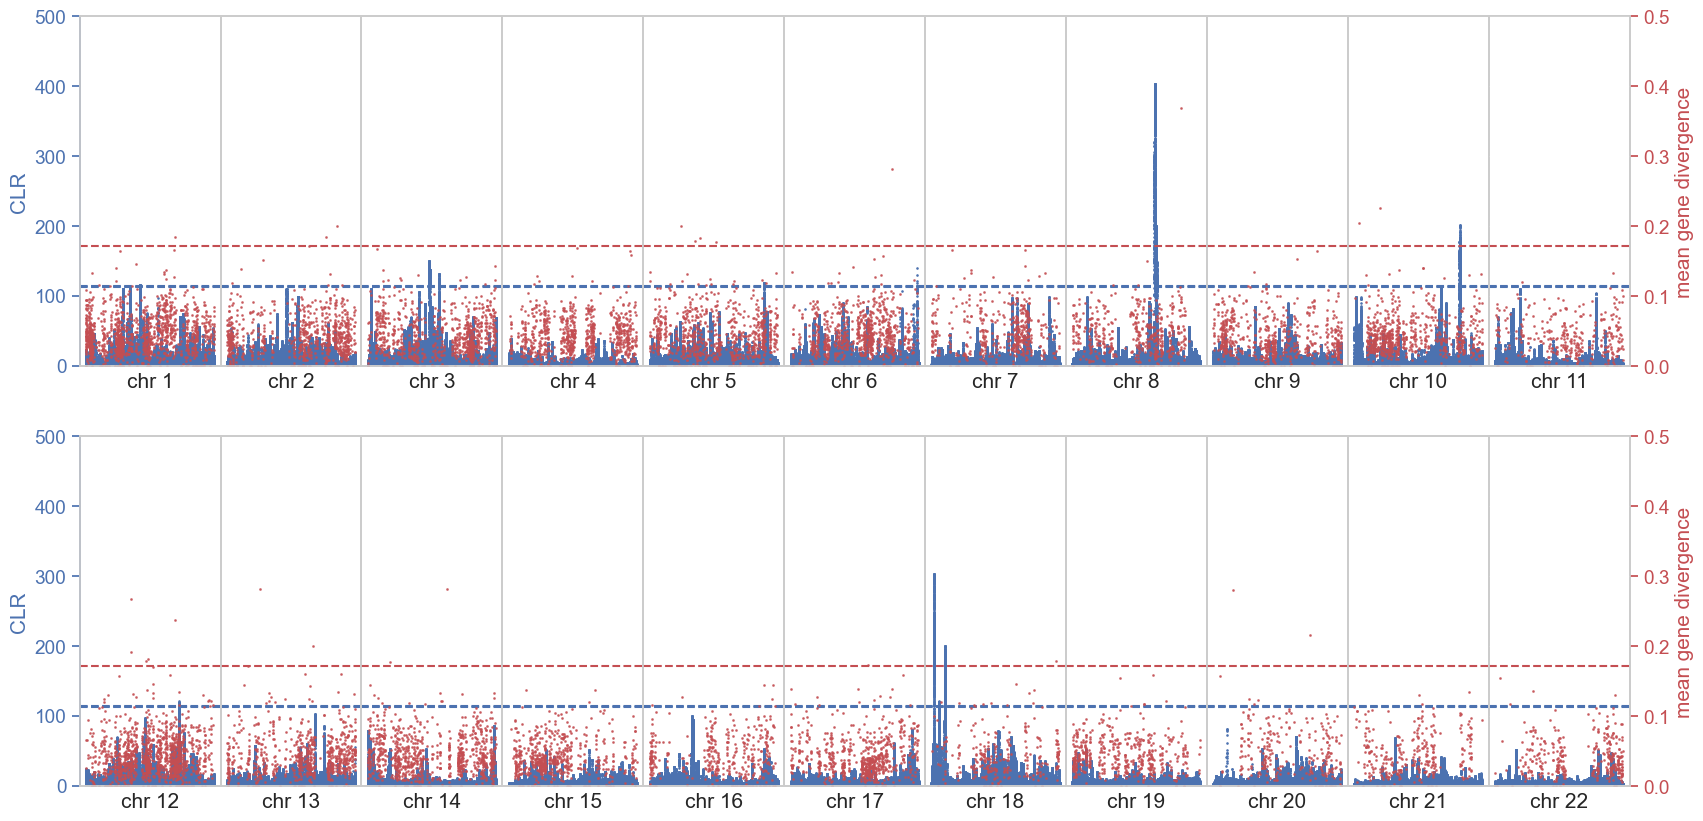

In [10]:
#Read in divergence information
ddf = pd.read_csv(r"/Volumes/WD/titi/mu/halSnps/exonic/divergence/mean_gene_divergence.bed", sep='\t', 
                 names=['chrom','start','end','gene', 'accessible', 'point_muts', 'divergence'])
ddf = ddf[ddf.accessible>100]
ddf = ddf[~ddf.gene.str.contains("LINC")]
ddf = ddf[~ddf.gene.str.contains("orf")]
ddf.divergence.describe()

#Read in neutral divergence to set threshold (obtained from Soni, Versoza et al. 2026)
tdf = pd.read_csv(r"/Volumes/WD/titi/mu/halSnps/1kb_divergence.SNPable.bed", sep='\t', names=['chrom','start','end','length', 'mutations', 'divergence'])
tdf = tdf[tdf.length>100]
n_div = tdf.divergence.quantile(0.999)

#Null thresholds
maxes={'sf_high': 113.79, 'bm_high': 280.24, 'sf_low':112.3, 'bm_low':236.6}

sns.set(rc={'figure.figsize':(20,10),'axes.facecolor':'white','axes.edgecolor': '.8'},font_scale=1.25)
fig, axs = plt.subplots(2,11)
for i,j in enumerate([x for x in range(15,26)]):
    df = pd.read_csv(r"/Volumes/WD/titi/sweep_scans/empirical_data/SF2_results/CM0808"+ str(j) + ".clr", sep='\t', header=0)
    tdf = ddf[ddf.chrom=="CM0808"+str(j)+".1"]
    axs[0,i].scatter(x=df.location, y=df['LR'], s=0.75)
    axs[0,i].axhline(maxes['sf_low'], color='b', linestyle='--')
    axs[0,i].axhline(maxes['sf_high'], color='b', linestyle='--')
    axs[0,i].set_xticks([])
    axs[0,i].set_ylim([-1, 500])
    if(j==15):
        axs[0,i].set_ylabel('CLR', color='b')
        axs[0,i].tick_params(axis='y', colors='b')
        axs[0,i].spines['left'].set_color('b')
    #    plt.text(s='Null threshold', x=0, y=maxes['100nt']+10)
    else:
        axs[0,i].set_yticks([])
    axs[0,i].set_xlabel('chr ' + str(j-14))

    ax2 = axs[0,i].twinx()
    ax2.scatter(x=tdf.start, y=tdf.divergence, color='r', s=1, alpha=0.75)
    ax2.axhline(n_div, color='r', linestyle='--')
    ax2.set_ylim([0, 0.5])
    if(j==25):
        ax2.set_ylabel('mean gene divergence', color='r')
        ax2.tick_params(axis='y', colors='r')
        #ax2.spines['right'].set_color('r')
    #    plt.text(s='Null threshold', x=0, y=maxes['100nt']+10)
    else:
        ax2.set_yticks([])
        
for i,j in enumerate([x for x in range(26,37)]):
    df = pd.read_csv(r"/Volumes/WD/titi/sweep_scans/empirical_data/SF2_results/CM0808"+ str(j) + ".clr", sep='\t', header=0)
    tdf = ddf[ddf.chrom=="CM0808"+str(j)+".1"]
    axs[1,i].scatter(x=df.location, y=df['LR'], s=0.75)
    axs[1,i].axhline(maxes['sf_low'], color='b', linestyle='--')
    axs[1,i].axhline(maxes['sf_high'], color='b', linestyle='--')
    axs[1,i].set_xticks([])
    axs[1,i].set_ylim([-1, 500])
    if(j==26):
        axs[1,i].set_ylabel('CLR', color='b')
        axs[1,i].tick_params(axis='y', colors='b')
        axs[1,i].spines['left'].set_color('b')
    else:
        axs[1,i].set_yticks([])
    axs[1,i].set_xlabel('chr ' + str(j-14))

    ax2 = axs[1,i].twinx()
    ax2.scatter(x=tdf.start, y=tdf.divergence, color='r', s=1, alpha=0.75)
    ax2.axhline(n_div, color='r', linestyle='--')
    ax2.set_ylim([0, 0.5])
    if(j==36):
        ax2.set_ylabel('mean gene divergence', color='r')
        ax2.tick_params(axis='y', colors='r')
        #ax2.spines['right'].set_color('r')
    #    plt.text(s='Null threshold', x=0, y=maxes['100nt']+10)
    else:
        ax2.set_yticks([])
    
#plt.suptitle('SF2')  
plt.subplots_adjust(wspace=0, hspace=0.2)
# plt.savefig('/Volumes/WD/titi/sweep_scans/plots/sweep_scans.png', format='png', bbox_inches='tight')
# plt.savefig('/Volumes/WD/titi/sweep_scans/plots/sweep_scans.pdf', format='pdf', bbox_inches='tight', dpi=300)

<h2>Figure 5</h2>

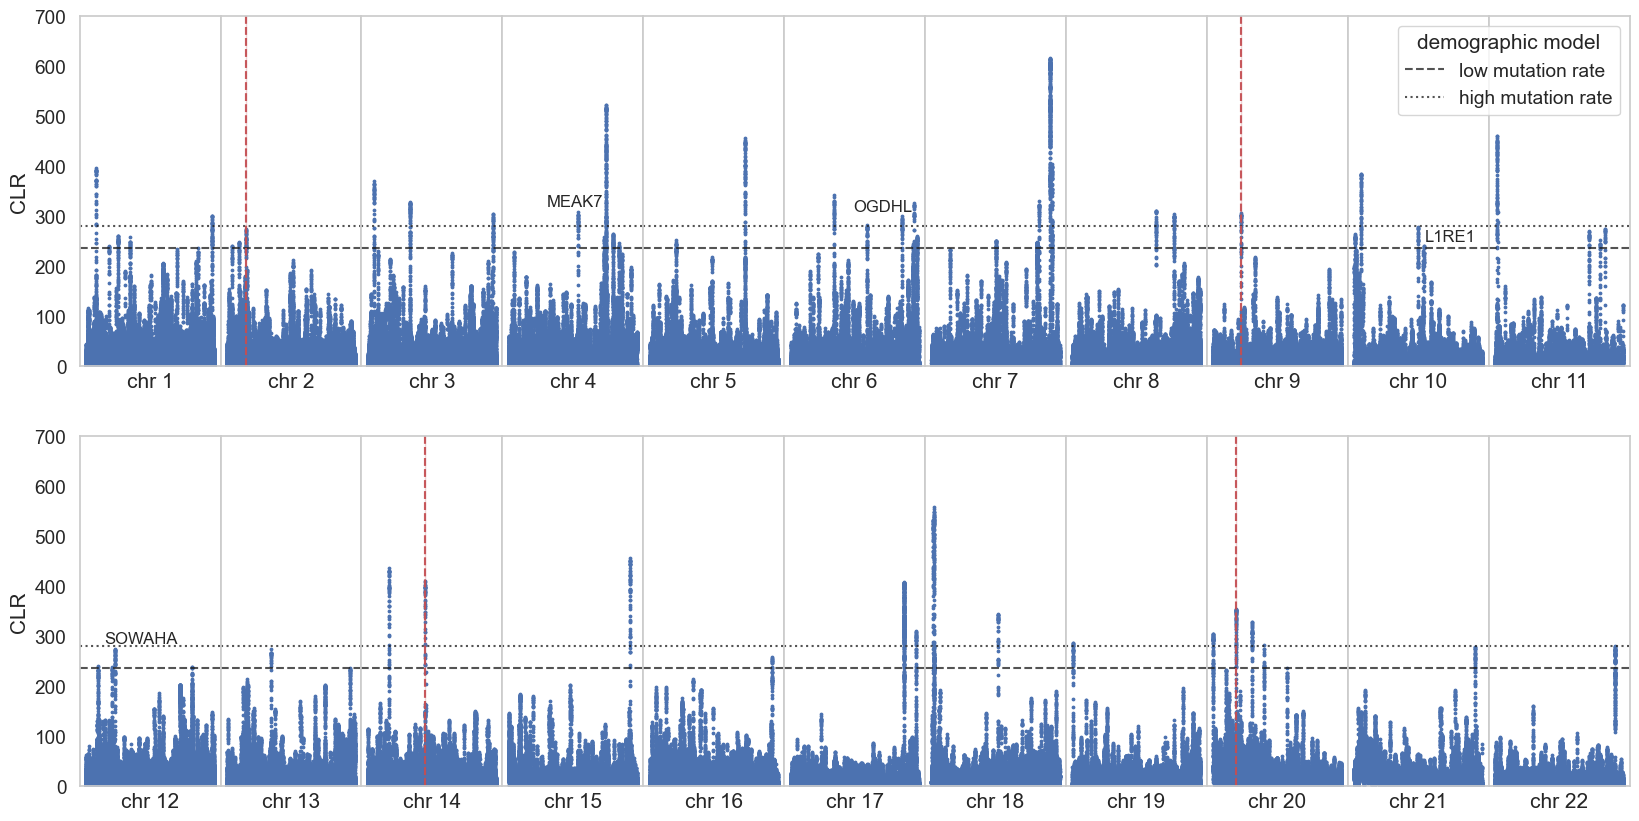

In [11]:
#Load in structural variant df
sv_df = pd.read_csv("/Volumes/WD/titi/sweep_scans/empirical_data/SV_bs_candidates.bed", sep='\t', names=['chrom', 'start', 'end', 'SV'])
sv_df = sv_df.drop_duplicates()
sv_df['length'] = sv_df.end - sv_df.start

peak_df = pd.DataFrame()
sns.set(rc={'figure.figsize':(20,10),'axes.facecolor':'white','axes.edgecolor': '.8'},font_scale=1.25)
for i in range(15,26):
    tdf = sv_df[sv_df.chrom==f"CM0808{i}.1"].reset_index(drop=True)
    df = pd.read_csv(r"/Volumes/WD/titi/sweep_scans/empirical_data/BM_results/CM0808"+ str(i) + ".clr", sep='\t', header=0)
    plt.subplot(2,11,i-14)
    plt.scatter(x=df.physPos, y=df['CLR'], s=3)
    plt.axhline(maxes['bm_low'], color='k', linestyle='--', alpha=0.75, label='low mutation rate')
    plt.axhline(maxes['bm_high'], color='k', linestyle='dotted', alpha=0.75, label='high mutation rate')
    plt.xticks([])
    plt.ylim([-1, 700])
    if(len(tdf)>0):
        plt.axvline(tdf.start[0], color='r', linestyle='--', alpha=0.75)
        plt.axvline(tdf.end[0], color='r', linestyle='--', alpha=0.75)
        plt.fill_betweenx([-5, 700], [tdf.start[0]], [tdf.end[0]], alpha=0.25, color='r')        
    if(i==15):
        plt.ylabel('CLR')
    #    plt.text(s='Null threshold', x=0, y=maxes['100nt']+10)
    else:
        plt.yticks([])
    plt.xlabel('chr ' + str(i-14))
    if(i==25):
        plt.legend(title='demographic model')

    if(i==18):
        plt.text(s='MEAK7', x=45236745, y=320, size=12)
    elif(i==20):
        plt.text(s='OGDHL', x=60916778, y=310, size=12)
    elif(i==24):
        plt.text(s='L1RE1', x=42026386, y=250, size=12)
        
for i in range(26, 37):
    tdf = sv_df[sv_df.chrom==f"CM0808{i}.1"].reset_index(drop=True)
    df = pd.read_csv(r"/Volumes/WD/titi/sweep_scans/empirical_data/BM_results/CM0808"+ str(i) + ".clr", sep='\t', header=0)
    plt.subplot(2,11,i-14)
    plt.scatter(x=df.physPos, y=df['CLR'], s=3)
    plt.axhline(maxes['bm_low'], color='k', linestyle='--', alpha=0.75, label='low mutation rate')
    plt.axhline(maxes['bm_high'], color='k', linestyle='dotted', alpha=0.75, label='high mutation rate')
    plt.xticks([])
    plt.ylim([-1, 700])
    if(len(tdf)>0):
        plt.axvline(tdf.start[0], color='r', linestyle='--', alpha=0.75)
        plt.axvline(tdf.end[0], color='r', linestyle='--', alpha=0.75)
        plt.fill_betweenx([-5, 700], [tdf.start[0]], [tdf.end[0]], alpha=0.25, color='r') 
        
    if(i==26):
        plt.ylabel('CLR')
        #plt.text(s='Null threshold', x=0, y=maxes['100nt']+10)
    else:
        plt.yticks([])
    plt.xlabel('chr ' + str(i-14))

    if(i==26):
        plt.text(s='SOWAHA', x=32937599, y=285, size=12)
    
#plt.suptitle('B0MAF (10 SNP windows)')    
plt.subplots_adjust(wspace=0, hspace=0.2)
#plt.savefig('/Volumes/WD/titi/sweep_scans/plots/balancing_selection_scans.png', format='png', bbox_inches='tight')
#plt.savefig('/Volumes/WD/titi/sweep_scans/plots/balancing_selection_scans.pdf', format='pdf', bbox_inches='tight', dpi=300)